# 12. Mención de honor

**Fuente:** `data/raw/mencionhonor.csv`  
**Salida:** `data/processed/mencion_honor.csv`

Menciones de honor / distinciones academicas obtenidas por el personal.

In [16]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [17]:
df = pc.leer_csv('mencionhonor.csv', low_memory=False)
df.head()

Leido mencionhonor.csv con encoding=utf-8-sig -> 5457 filas, 12 columnas


,IDMENCIONHONOR,NOMBREMENCION,IDINSTITUCION,IDPAIS,ULTIMO_CAMBIO,IDPERSONA,FECHA,INSTITUCION,REFARCHIVO,TIPO,SITIOWEB,IDUSUARIO
0,1480,SEGUNDA MENCIÓN DE HONOR,NaN,1,2016-03-09-10.22.57.442071,76290,2002-09-05,UNIVERSIDAD DE GUAYAQUIL,NaN,NaN,NaN,NaN
1,1481,DIPLOMA DE HONOR,NaN,1,2016-03-10-15.46.15.340093,54029,2010-10-28,LA ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,NaN,NaN,NaN,NaN
2,1482,MEDALLA DE ORO Y DIPLOMA DE HONOR,NaN,1,2016-03-10-15.47.10.588984,54029,2010-10-29,LA ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,NaN,NaN,NaN,NaN
3,1483,TINKER RESEARCH FIELD GRANT,NaN,4,2016-03-11-23.03.43.754136,7726,2016-02-09,LATIN AMERICAN AND CARIBEAN CENTER/ FLORIDA IN...,NaN,NaN,NaN,NaN
4,1484,CERTIFICACIÓN HONORÍFICA,NaN,1,2016-03-15-14.52.28.872800,86531,2010-02-19,UNIVERSIDAD CATÓLICA DE SANTIAGO DE GUAYAQUIL,NaN,NaN,NaN,NaN


## 2. Exploración inicial

In [18]:
pc.resumen(df, 'mencion_honor')

--- Resumen mencion_honor ---
Dimensiones: 5457 filas x 12 columnas
Filas duplicadas: 0
Columnas con nulos (%):
IDUSUARIO        98.2
SITIOWEB         81.7
IDINSTITUCION    80.6
TIPO             74.2
REFARCHIVO       40.9
INSTITUCION       1.3
dtype: float64


In [19]:
df.dtypes

IDMENCIONHONOR      int64
NOMBREMENCION      object
IDINSTITUCION     float64
IDPAIS              int64
ULTIMO_CAMBIO      object
IDPERSONA           int64
FECHA              object
INSTITUCION        object
REFARCHIVO         object
TIPO               object
SITIOWEB           object
IDUSUARIO         float64
dtype: object

## 3. Limpieza

In [20]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.98)
df = pc.quitar_columnas_constantes(df)
df = df.drop(columns=['ULTIMO_CAMBIO'], errors='ignore')

Columnas eliminadas por tener >= 98% de nulos: ['IDUSUARIO']


## 5. Tipado de fechas e identificadores

In [21]:
df = pc.castear_fechas(df, ['ULTIMO_CAMBIO', 'FECHA'])
df = pc.castear_enteros(df, ['IDMENCIONHONOR', 'IDINSTITUCION', 'IDPAIS', 'IDPERSONA'])
df = pc.convertir_sn_a_binario(df, ['SITIOWEB'])

Columnas S/N convertidas a binario (1/0): ['SITIOWEB']


## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Menciones de honor por año**.

<Axes: title={'center': 'Menciones de honor por año'}, xlabel='Año', ylabel='N.º de registros'>

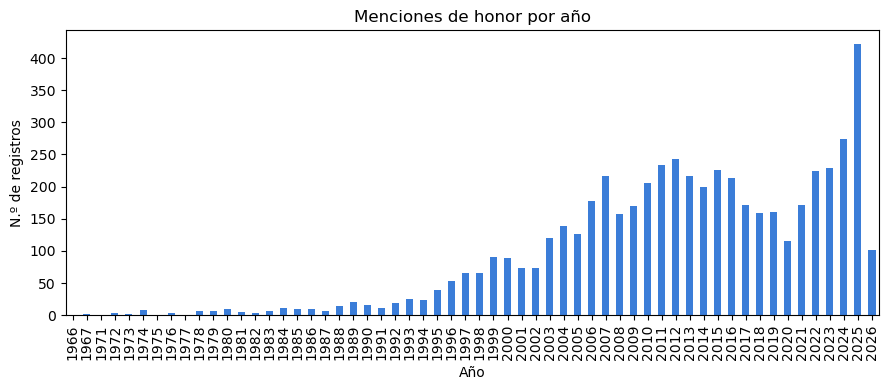

In [23]:
pc.grafico_por_anio(df['FECHA'], 'Menciones de honor por año')

**Instituciones que más otorgan menciones de honor**.

<Axes: title={'center': 'Top 10 instituciones que otorgan menciones'}, ylabel='INSTITUCION'>

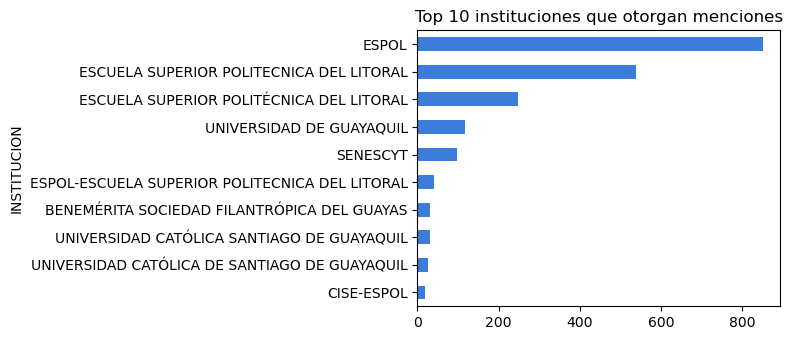

In [24]:
pc.grafico_barras(df['INSTITUCION'], 'Top 10 instituciones que otorgan menciones', top=10)

**Distribución por tipo de mención** (cuando está disponible).

<Axes: title={'center': 'Menciones por TIPO'}, xlabel='TIPO'>

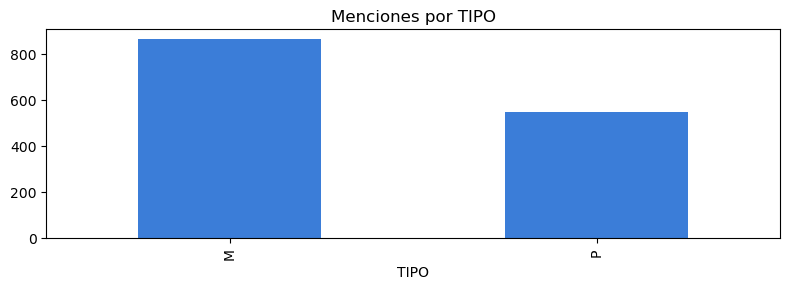

In [25]:
pc.grafico_barras(df['TIPO'], 'Menciones por TIPO', horizontal=False)

## 7. Verificación final

In [26]:
pc.resumen(df, 'mencion_honor (procesado)')
df.head()

--- Resumen mencion_honor (procesado) ---
Dimensiones: 5457 filas x 10 columnas
Filas duplicadas: 0
Columnas con nulos (%):
IDINSTITUCION    80.6
TIPO             74.2
REFARCHIVO       40.9
INSTITUCION       1.3
FECHA             0.1
dtype: float64


,IDMENCIONHONOR,NOMBREMENCION,IDINSTITUCION,IDPAIS,IDPERSONA,FECHA,INSTITUCION,REFARCHIVO,TIPO,SITIOWEB
0,1480,SEGUNDA MENCIÓN DE HONOR,<NA>,1,76290,2002-09-05,UNIVERSIDAD DE GUAYAQUIL,<NA>,<NA>,0
1,1481,DIPLOMA DE HONOR,<NA>,1,54029,2010-10-28,LA ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,<NA>,<NA>,0
2,1482,MEDALLA DE ORO Y DIPLOMA DE HONOR,<NA>,1,54029,2010-10-29,LA ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL,<NA>,<NA>,0
3,1483,TINKER RESEARCH FIELD GRANT,<NA>,4,7726,2016-02-09,LATIN AMERICAN AND CARIBEAN CENTER/ FLORIDA IN...,<NA>,<NA>,0
4,1484,CERTIFICACIÓN HONORÍFICA,<NA>,1,86531,2010-02-19,UNIVERSIDAD CATÓLICA DE SANTIAGO DE GUAYAQUIL,<NA>,<NA>,0


## 8. Guardado en data/processed

In [27]:
pc.guardar_procesado(df, 'mencion_honor.csv')

Guardado: D:\Proyecto_Tesis\data\processed\mencion_honor.csv (5457 filas x 10 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/mencion_honor.csv')